## Baro Array - Coherence

### Importing

In [1]:
import os
import gc
import numpy as np
import matplotlib.pyplot as plt
import obspy
import pandas as pd

from obspy import Stream

from functions.baro_array import baroArray

In [2]:
if os.uname().nodename == 'lighthouse':
    root_path = '/home/andbro/'
    data_path = '/home/andbro/kilauea-data/'
    archive_path = '/home/andbro/freenas/'
    bay_path = '/home/andbro/ontap-ffb-bay200/'
    lamont_path = '/home/andbro/lamont/'
elif os.uname().nodename == 'kilauea':
    root_path = '/home/brotzer/'
    data_path = '/import/kilauea-data/'
    archive_path = '/import/freenas-ffb-01-data/'
    bay_path = '/import/ontap-ffb-bay200/'
    lamont_path = '/lamont/'
elif os.uname().nodename in ['lin-ffb-01', 'ambrym', 'hochfelln']:
    root_path = '/home/brotzer/'
    data_path = '/import/kilauea-data/'
    archive_path = '/import/freenas-ffb-01-data/'
    bay_path = '/import/ontap-ffb-bay200/'
    lamont_path = '/lamont/'

### Setting Variables

In [3]:
config = {}

# config['klim'] = 50.
# config['kstep'] = config['klim'] / 100.

# example 1
# config['tbeg'] = obspy.UTCDateTime("2024-03-16 06:00")
# config['tend'] = obspy.UTCDateTime("2024-03-16 18:00")

# example 2
# config['tbeg'] = obspy.UTCDateTime("2024-03-23 06:00")
# config['tend'] = obspy.UTCDateTime("2024-03-23 17:00")

# example 3
# config['tbeg'] = obspy.UTCDateTime("2024-03-23 00:00")
# config['tend'] = obspy.UTCDateTime("2024-03-25 00:00")

# example 4
config['tbeg'] = obspy.UTCDateTime("2024-09-09 00:00")
config['tend'] = obspy.UTCDateTime("2024-09-10 00:00")


config['seeds'] = [
                   'BW.PROMY.04.LDI',
                   'BW.GELB..LDO',
                   'BW.GRMB..LDO',
                   'BW.ALFT..LDO',
                   'BW.BIB..LDO',
                   'BW.TON..LDO',
]

config['fmin'] = 1e-4
config['fmax'] = 10e-3

config['path_to_figs'] = data_path+"/romy_baro/figures/"


config['coos'] = { "ALFT":{"lon":11.2795 , "lat":48.142334, "height":593.0},
                   "GELB":{"lon":11.2514 , "lat":48.1629, "height":628.0},
                   "GRMB":{"lon":11.2635 , "lat":48.1406, "height":656.0},
                   "TON":{"lon":11.288809 , "lat":48.173897, "height":564.0},
                   "BIB":{"lon":11.2473 , "lat":48.1522, "height":599.0},
                   "PROMY":{"lon":11.275501 , "lat":48.162941, "height":571.0},
                  }

In [4]:
brmy = baroArray(seeds=config['seeds'],
                 coords=config['coos'],
                 out_seed="BW.BRMY..BDX",
                )


In [5]:
brmy.load_data(tbeg=config['tbeg'],
               tend=config['tend'],
               path_to_sds=archive_path+"temp_archive/",
               verbose=False
              )

In [6]:
brmy.st0

6 Trace(s) in Stream:
BW.PROMY.04.LDI | 2024-09-09T00:00:00.000000Z - 2024-09-10T00:00:00.000000Z | 1.0 Hz, 86401 samples
BW.GELB..LDO    | 2024-09-09T00:00:00.000000Z - 2024-09-10T00:00:00.000000Z | 1.0 Hz, 86401 samples
BW.GRMB..LDO    | 2024-09-09T00:00:00.000000Z - 2024-09-10T00:00:00.000000Z | 1.0 Hz, 86401 samples
BW.ALFT..LDO    | 2024-09-09T00:00:00.000000Z - 2024-09-10T00:00:00.000000Z | 1.0 Hz, 86401 samples
BW.BIB..LDO     | 2024-09-09T00:00:00.000000Z - 2024-09-10T00:00:00.000000Z | 1.0 Hz, 86401 samples
BW.TON..LDO     | 2024-09-09T00:00:00.000000Z - 2024-09-10T00:00:00.000000Z | 1.0 Hz, 86401 samples

In [7]:
brmy.preprocessing(config['fmin'], config['fmax'])

In [8]:
brmy.compute_gradient(reference="BW.PROMY",
                      verbose=False
                     )

In [9]:
brmy.get_angle()
brmy_ang = brmy.angles

brmy.get_absolute_gradient()
brmy_abs = brmy.abs_gradient

In [10]:
# brmy.st0.plot()

### Plotting

/home/andbro/notebooks/RomyBaro/functions/baro_array.py:471: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax4.set_xticklabels(["N", "-45°", "-90°", "-135°", "180°", "135°", "90°", "45°"])


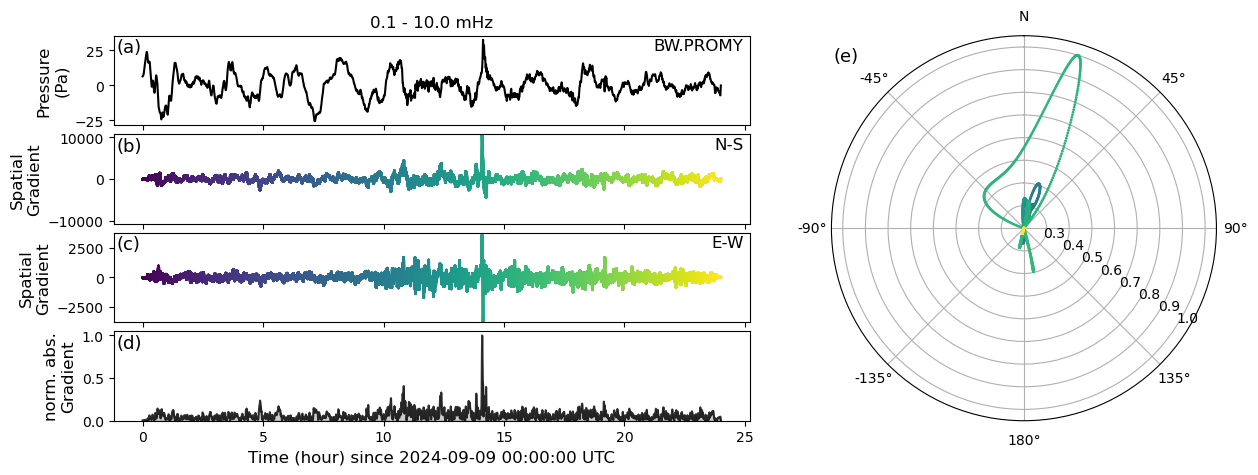

In [11]:
brmy.makeplot(plot=True)

/tmp/ipykernel_486742/2227352484.py:94: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax4.set_xticklabels(["N", "-45°", "-90°", "-135°", "180°", "135°", "90°", "45°"])


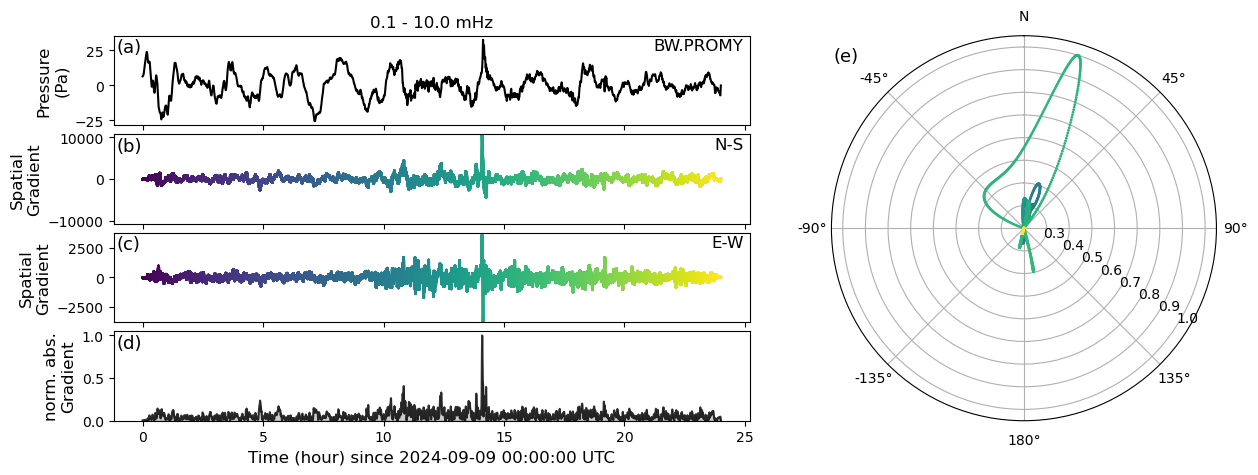

In [108]:
def __makeplot():

    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.gridspec import GridSpec

    t = brmy.gradient.select(channel="*N")[0].times()
    N = brmy.gradient.select(channel="*N")[0].data
    E = brmy.gradient.select(channel="*E")[0].data

    # pressure data
    tt = brmy.st.select(station="PROMY")[0].times()
    pp = brmy.st.select(station="PROMY")[0].data

    # normalized absolute gradient
    r = brmy_abs / max(brmy_abs)

    # specify limit for r
    rlim = 0.2

    # angle as radians
    theta = np.deg2rad(brmy_ang)

    # ___________________________________________

    tscale, tunit = 1/3600, "hour"

    gscale, gunit = 1e6, ""

    Ncol, Nrow = 9, 4

    font = 12

    lw = 1

    fig = plt.figure(figsize=(15, 5))

    gs1 = GridSpec(Nrow, Ncol, figure=fig, hspace=0.1, wspace=0.2)
    # gs2 = GridSpec(Nrow, Ncol, figure=fig, hspace=1)

    ax0 = fig.add_subplot(gs1[0, :5])
    ax1 = fig.add_subplot(gs1[1, :5])
    ax2 = fig.add_subplot(gs1[2, :5])
    ax3 = fig.add_subplot(gs1[3, :5])
    ax4 = fig.add_subplot(gs1[0:4, 5:], polar=True)

    axes = [ax0, ax1, ax2, ax3, ax4]

    # ___________________________________________

    ax0.plot(tt*tscale, pp, color="k")

    ax0.set_xticklabels([])
    ax0.set_ylabel(f"Pressure\n(Pa)", fontsize=font)
    # ax0.legend(loc=1)
    ax0.text(0.99, 0.97, brmy.reference, ha="right", va="top", transform=ax0.transAxes, fontsize=font)

    # ___________________________________________

    # ax1.plot(t*tscale, N*gscale, color=t*tscale)
    ax1.scatter(t*tscale, N*gscale, c=t*tscale, s=1, label="N-S")
    ax1.set_xticklabels([])
    ax1.set_ylim(-max(abs(N))*gscale, max(abs(N))*gscale)
    ax1.set_ylabel(f"Spatial\nGradient", fontsize=font)
    # ax1.legend(loc=1, handlelength=0, handletextpad=1)
    ax1.text(0.99, 0.97, "N-S", ha="right", va="top", transform=ax1.transAxes, fontsize=font)

    # ___________________________________________

    # ax2.plot(t*tscale, E*gscale)
    ax2.scatter(t*tscale, E*gscale, c=t*tscale, s=1, label="E-W")
    ax2.set_xticklabels([])
    ax2.set_ylim(-max(abs(E))*gscale, max(abs(E))*gscale)
    ax2.set_ylabel(f"Spatial\nGradient", fontsize=font)
    # ax2.legend(loc=1, handlelength=-1, handletextpad=0)
    ax2.text(0.99, 0.97, "E-W", ha="right", va="top", transform=ax2.transAxes, fontsize=font)

    # ___________________________________________

    ax3.plot(t*tscale, r, color='k', alpha=0.8)
    ax3.fill_between(t*tscale, r, color='k', alpha=0.2)
    ax3.set_ylim(0, 1.05)
    ax3.set_ylabel(f"norm. abs.\nGradient", fontsize=font)

    # ___________________________________________

    ax4.scatter(theta[r>rlim], r[r>rlim], c=t[r>rlim], s=1, zorder=2)
    ax4.set_theta_zero_location("N")
    ax4.set_rmin(0.2)
    ax4.set_rmax(1.05)
    ax4.set_rlabel_position(-122.5)
    ax4.grid(True)

    ax4.set_xticklabels(["N", "-45°", "-90°", "-135°", "180°", "135°", "90°", "45°"])

    ax3.set_xlabel(f"Time ({tunit}) since {config['tbeg'].date} {str(config['tbeg'].time)[:10]} UTC", fontsize=font)

    ax0.set_title(f"{config['fmin']*1e3} - {config['fmax']*1e3} mHz", fontsize=font)

    for _k, (ll, ax) in enumerate(zip(['(a)','(b)','(c)','(d)', '(e)'], axes)):
        ax.text(0.005, 0.97, ll, ha="left", va="top", transform=ax.transAxes, fontsize=font+1)

    plt.show();
    return fig

fig = __makeplot()

# fig.savefig(config['path_to_figs']+f"RB_{config['tbeg'].date}_gradient.png", format="png", dpi=150, bbox_inches='tight')
